# Sampling from a Population

The law of averages also applies when random samples are drawn from individuals in a large population.

As an example, we will study a population of flight delay times. The DataFrame `united` contains data for United Airlines domestic flights departing from San Francisco during the summer of 2015.

There are 13,825 rows, each corresponding to a flight. The columns include the flight date, flight number, destination airport code, and departure delay time in minutes. Some delay times are negative because those flights departed early.

In [1]:
import pandas as pd
path_data = "../../../assets/data/"
import matplotlib
matplotlib.use("Agg")
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")
import numpy as np

In [2]:
united = pd.read_csv(path_data + 'united_summer2015.csv')
united

,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1,6/1/15,217,EWR,28
2,6/1/15,237,STL,-3
3,6/1/15,250,SAN,0
4,6/1/15,267,PHL,64
...,...,...,...,...
13820,8/31/15,1978,LAS,-4
13821,8/31/15,1993,IAD,8
13822,8/31/15,1994,ORD,3
13823,8/31/15,2000,PHX,-1


One flight departed 16 minutes early and one flight was 580 minutes late. Most delay times were between about -10 and 200 minutes, as shown in the histogram below.

In [3]:
united['Delay'].min()

np.int64(-16)

In [4]:
united['Delay'].max()

np.int64(580)

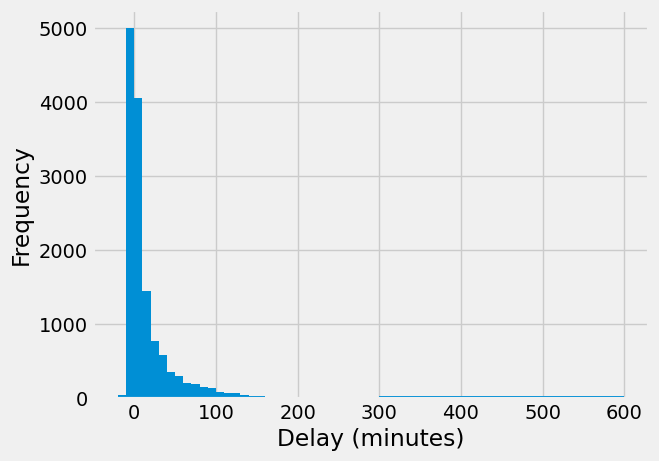

In [5]:
delay_bins = np.append(np.arange(-20, 301, 10), 600)
united['Delay'].plot.hist(bins=delay_bins)
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.show()

For the purposes of this section, it is useful to focus on the bulk of the data and ignore the small percentage of flights delayed by more than 200 minutes. This restriction is solely for visual convenience; the data remain unchanged.

In [6]:
len(united[united['Delay'] > 200]) / len(united)

0.008390596745027125

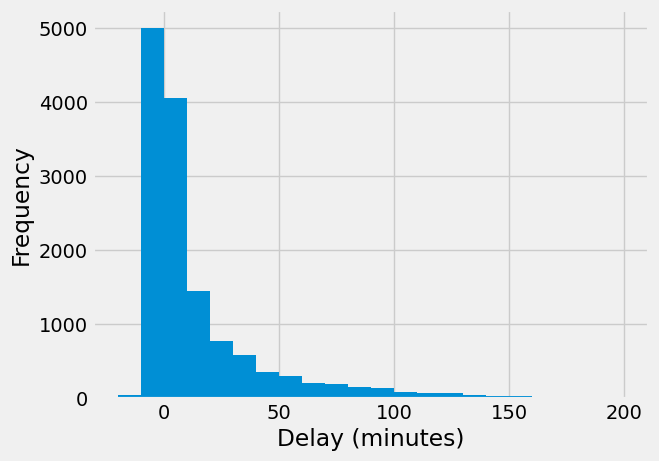

In [7]:
delay_bins = np.arange(-20, 201, 10)
united['Delay'].plot.hist(bins=delay_bins)
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.show()

The bar covering delays from 0 to 10 minutes contains a substantial fraction of flights. We can confirm the proportion directly by counting rows.

In [8]:
len(united[(united['Delay'] >= 0) & (united['Delay'] < 10)]) / len(united)

0.2935985533453888

## Empirical Distribution of the Sample

Now think of the 13,825 flights as a population and draw random samples from it with replacement. The function below takes a sample size as its argument and draws an empirical histogram of the sampled delay times.

In [9]:
def empirical_hist_delay(n):
    sample = united.sample(n=n, replace=True)
    sample['Delay'].plot.hist(bins=delay_bins)
    plt.xlabel('Delay (minutes)')
    plt.ylabel('Frequency')
    plt.title(f'Empirical Histogram of {n} Sampled Flights')
    plt.show()

As we saw with die rolls, as the sample size increases, the empirical histogram of the sample more closely resembles the histogram of the population.

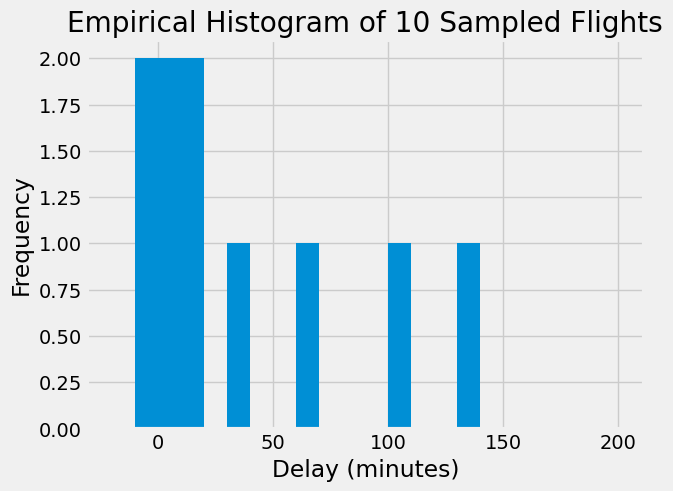

In [10]:
empirical_hist_delay(10)

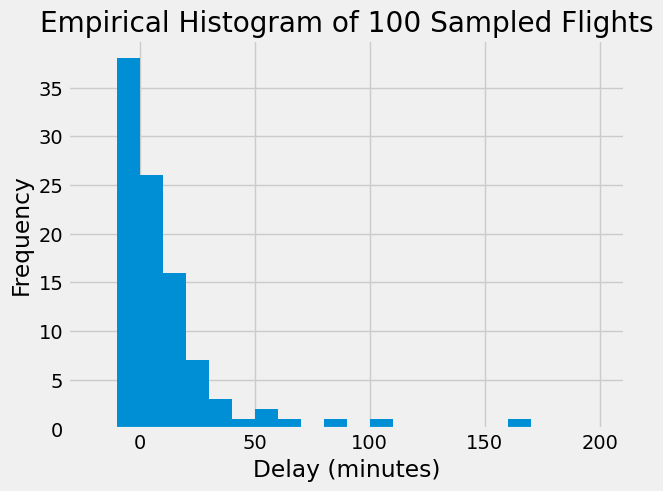

In [11]:
empirical_hist_delay(100)

The largest discrepancies tend to occur among values that are rare in the population. In this dataset, those values lie in the right tail of the distribution. As the sample size grows, even those rare values begin to appear in approximately the correct proportions.

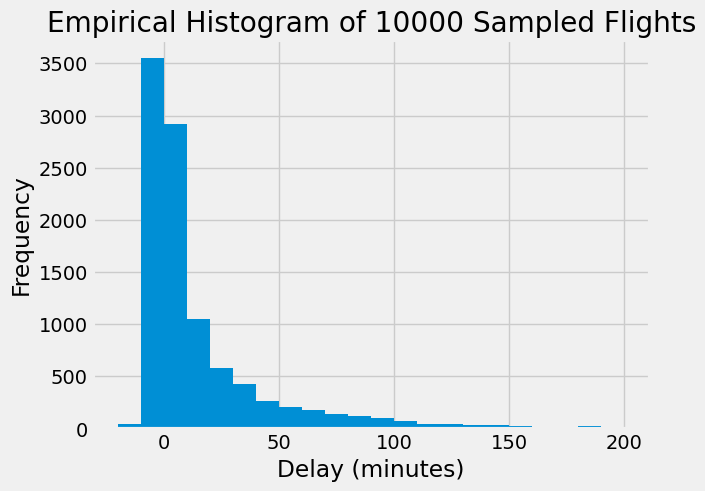

In [13]:
empirical_hist_delay(10000)

## Convergence of the Empirical Histogram of the Sample

What we have observed can be summarized as follows:

> For a large random sample, the empirical histogram of the sample resembles the histogram of the population with high probability.

This principle justifies the use of large random samples in statistical inference. Because a large random sample is likely to resemble the population from which it was drawn, quantities computed from the sample are likely to be close to the corresponding quantities in the population.